# 🚀 Practice Day 03

**📅 Date:** 2026-09-14  
**📁 Category:** Phase 1 · 데이터 클리닝 (Round 1/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Diagnose and fix common real-world data quality issues in a single table (한 테이블에서 흔한 데이터 품질 문제 진단·해결)
- Practice the full Data Cleaning checklist: missing values, duplicates, wrong types, column renaming, dropping useless columns (결측치·중복·타입·컬럼명·불필요 컬럼까지 클리닝 체크리스트 전체 연습)
- Only compute business metrics after the data is properly cleaned (정제가 끝난 뒤에만 비즈니스 지표 계산)

---
# 📂 Dataset

**Dataset Name:** Gym Membership Data — Raw / Uncleaned (헬스장 회원 데이터 - 정제 전)

**Source:** Synthetically generated for practice, fixed random seed, deliberately seeded with common real-world data quality issues (연습용으로 코드에서 직접 생성, seed 고정, 실제 데이터에서 흔한 품질 문제를 의도적으로 포함)

**Description:** 274 gym membership records (260 unique members + 14 exact duplicate rows). Intentionally messy: missing `phone`/`birth_date` values, inconsistent `membership_type` capitalization/spacing (14 raw variants of what should be 3 categories), `monthly_fee` stored as mixed-format strings (plain digits, comma-formatted, some with a "KRW" suffix) including a few clearly invalid entries (zero, negative, an extreme outlier), an awkwardly-cased `PhoneNum` column, and a completely empty `notes` column. Nothing has been cleaned yet.
(회원 274건(고유 260 + 중복 14건). phone·birth_date 결측치, membership_type 표기 불일치(3개 카테고리가 14가지 원본 표기로 존재), 문자 형식이 섞인 monthly_fee(쉼표·KRW 접미사 포함, 0/음수/극단값 등 이상치 포함), 어색한 컬럼명 PhoneNum, 완전히 빈 notes 컬럼까지 아직 아무것도 정제되지 않은 상태입니다.)

## Dataset Preview

In [47]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

n_members = 260

first_names = ['James', 'Emma', 'Liam', 'Olivia', 'Noah', 'Ava', 'Ethan', 'Sophia', 'Mason', 'Mia',
               'Lucas', 'Isabella', 'Logan', 'Amelia', 'Henry', 'Harper', 'Jack', 'Evelyn', 'Owen', 'Chloe']
last_names = ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia', 'Miller', 'Davis', 'Wilson', 'Taylor']
names = [f'{np.random.choice(first_names)} {np.random.choice(last_names)}' for _ in range(n_members)]

member_id = [f'MEM-{i+1:04d}' for i in range(n_members)]
phone = [f'555-{np.random.randint(1000, 9999)}-{np.random.randint(1000, 9999)}' for _ in range(n_members)]
birth_date = pd.to_datetime('1960-01-01') + pd.to_timedelta(np.random.randint(0, 365 * 48, n_members), unit='D')
membership_type_clean = np.random.choice(['VIP', 'Standard', 'Basic'], size=n_members, p=[0.15, 0.45, 0.40])
monthly_fee_map = {'VIP': 150000, 'Standard': 90000, 'Basic': 50000}
monthly_fee = np.array([monthly_fee_map[m] + np.random.randint(-3000, 3000) for m in membership_type_clean])
signup_date = pd.to_datetime('2024-01-01') + pd.to_timedelta(np.random.randint(0, 550, n_members), unit='D')

df = pd.DataFrame({
    'member_id': member_id,
    'name': names,
    'phone': phone,
    'birth_date': birth_date,
    'membership_type': membership_type_clean,
    'monthly_fee': monthly_fee,
    'signup_date': signup_date,
})

# --- inject realistic messiness (this is what a raw export often looks like) ---

# missing values
missing_phone_idx = np.random.choice(df.index, size=20, replace=False)
df.loc[missing_phone_idx, 'phone'] = None
missing_birth_idx = np.random.choice(df.index, size=15, replace=False)
df.loc[missing_birth_idx, 'birth_date'] = pd.NaT

# inconsistent category formatting (case / whitespace)
def messy_case(x):
    r = np.random.random()
    if r < 0.15:
        return x.upper()
    elif r < 0.30:
        return x.lower()
    elif r < 0.40:
        return f' {x}'
    elif r < 0.50:
        return f'{x} '
    return x

df['membership_type'] = df['membership_type'].apply(messy_case)

# monthly_fee stored as mixed-format strings instead of numbers
def messy_fee(v):
    r = np.random.random()
    if r < 0.35:
        return f'{v:,}'
    elif r < 0.50:
        return f'{v:,} KRW'
    return str(v)

df['monthly_fee'] = df['monthly_fee'].apply(messy_fee)

# a few clearly invalid fee entries (data entry errors)
bad_fee_idx = np.random.choice(df.index, size=4, replace=False)
df.loc[bad_fee_idx, 'monthly_fee'] = ['0', '-50000', '0 KRW', '5000000']

# duplicate rows
dup_rows = df.sample(n=14, random_state=7)
df = pd.concat([df, dup_rows], ignore_index=True)
df = df.sample(frac=1, random_state=3).reset_index(drop=True)

# a useless empty column + an awkwardly-named column
df['notes'] = np.nan
df = df.rename(columns={'phone': 'PhoneNum'})

df.head(10)

,member_id,name,PhoneNum,birth_date,membership_type,monthly_fee,signup_date,notes
0,MEM-0218,Isabella Johnson,555-8196-4368,2007-06-03,Basic,"52,481",2024-07-18,NaN
1,MEM-0068,Emma Taylor,NaN,1998-06-30,Basic,"51,181 KRW",2024-06-09,NaN
2,MEM-0205,Ethan Brown,555-1094-3674,1965-02-11,Basic,"49,359",2024-07-10,NaN
3,MEM-0017,Liam Jones,555-2810-7588,1962-04-02,BASIC,47619,2024-02-05,NaN
4,MEM-0026,Henry Williams,555-8576-1823,1997-12-11,Standard,87281,2024-06-08,NaN
5,MEM-0112,Mia Williams,555-7937-7190,1979-01-21,Basic,"48,000",2024-10-15,NaN
6,MEM-0066,Logan Miller,555-8140-4636,2006-08-16,Standard,91612,2025-02-09,NaN
7,MEM-0032,Evelyn Taylor,555-7190-2256,1972-07-02,Basic,52178,2024-09-15,NaN
8,MEM-0140,Amelia Garcia,555-3739-6401,1981-12-03,VIP,"150,848",2024-10-13,NaN
9,MEM-0217,Chloe Davis,555-6109-5146,2007-02-11,Basic,"48,708 KRW",2024-10-10,NaN


## Dataset Information


In [48]:
# Dataset Information
print(df.shape)
df.info()
df.describe(include='all')

(274, 8)
<class 'pandas.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   member_id        274 non-null    str           
 1   name             274 non-null    str           
 2   PhoneNum         253 non-null    str           
 3   birth_date       257 non-null    datetime64[us]
 4   membership_type  274 non-null    str           
 5   monthly_fee      274 non-null    str           
 6   signup_date      274 non-null    datetime64[us]
 7   notes            0 non-null      float64       
dtypes: datetime64[us](2), float64(1), str(5)
memory usage: 17.3 KB


,member_id,name,PhoneNum,birth_date,membership_type,monthly_fee,signup_date,notes
count,274,274,253,257,274,274,274,0.0
unique,260,141,240,NaN,14,259,NaN,NaN
top,MEM-0205,Ethan Brown,555-1094-3674,NaN,Basic,"49,359",NaN,NaN
freq,2,6,2,NaN,59,2,NaN,NaN
mean,NaN,NaN,NaN,1984-02-17 16:31:45.058365,NaN,NaN,2024-10-17 17:25:50.364963,NaN
min,NaN,NaN,NaN,1960-03-01 00:00:00,NaN,NaN,2024-01-07 00:00:00,NaN
25%,NaN,NaN,NaN,1971-03-14 00:00:00,NaN,NaN,2024-05-29 12:00:00,NaN
50%,NaN,NaN,NaN,1984-02-24 00:00:00,NaN,NaN,2024-10-13 12:00:00,NaN
75%,NaN,NaN,NaN,1996-07-20 00:00:00,NaN,NaN,2025-03-11 00:00:00,NaN
max,NaN,NaN,NaN,2007-06-21 00:00:00,NaN,NaN,2025-07-03 00:00:00,NaN


---
# ❓ Business Questions

1. How many missing values does each column have, and how many fully duplicate rows exist? (컬럼별 결측치는 몇 개이며, 완전히 중복된 행은 몇 개인가?)
2. How many distinct raw values does `membership_type` contain before cleaning, and what 3 categories should they be standardized to? (클리닝 전 membership_type에는 몇 가지 표기가 존재하며, 어떤 3가지로 표준화해야 하는가?)
3. After converting `monthly_fee` to a numeric type, which rows have suspicious values (zero, negative, or an extreme outlier)? (monthly_fee를 숫자형으로 변환한 뒤, 0/음수/극단값 등 의심스러운 값을 가진 행은?)
4. Once cleaned, what is the average monthly fee by membership type? (클리닝 후, 회원 등급별 평균 월 회비는?)
5. Once cleaned, how many new members signed up each month? (클리닝 후, 월별 신규 가입자 수는?)

---
# 🛠 Skills Used
- [x] Python
- [x] NumPy — used to generate the messy practice dataset with a fixed seed  
  (고정 seed로 지저분한 연습 데이터를 생성하는 데 사용)
- [x] Pandas — missing/duplicate checks, `str` cleaning, `to_numeric`, `groupby`  
  (결측·중복 확인, 문자열 정리, 숫자 변환, groupby)
- [ ] SQL
- [x] Matplotlib — bar chart (fee by type) and line chart (monthly signups)  
  (등급별 회비 막대, 월별 가입 선 차트)
- [ ] Other:


---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — `phone` 21, `birth_date` 17, `notes` 274  
  (phone 21, birth_date 17, notes 274)
- [x] Duplicate Rows — 14 (dropped in Q1)  
  (중복 14건, Q1에서 삭제)
- [x] Wrong Data Types — `monthly_fee` was string; standardized in Q3  
  (monthly_fee가 문자였음, Q3에서 숫자로)
- [x] Rename Columns — `PhoneNum` → `phone` (Q1)  
  (Q1에서 컬럼명 정리)
- [x] Drop Columns — empty `notes` dropped in Q1  
  (Q1에서 빈 notes 삭제)


In [49]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
member_id            0
name                 0
PhoneNum            21
birth_date          17
membership_type      0
monthly_fee          0
signup_date          0
notes              274
dtype: int64

Duplicate rows: 14

Dtypes
member_id                     str
name                          str
PhoneNum                      str
birth_date         datetime64[us]
membership_type               str
monthly_fee                   str
signup_date        datetime64[us]
notes                     float64
dtype: object

Column names
['member_id', 'name', 'PhoneNum', 'birth_date', 'membership_type', 'monthly_fee', 'signup_date', 'notes']

Text columns — unique counts
member_id          260
name               141
PhoneNum           240
membership_type     14
monthly_fee        259
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** How many missing values does each column have, and how many fully duplicate rows exist? (컬럼별 결측치는 몇 개이며, 완전히 중복된 행은 몇 개인가?)

**Result:** Missing: `PhoneNum` 21, `birth_date` 17, `notes` 274; all other columns 0. Exact duplicate rows: **14** (274 rows = 260 members + 14 copies).  
(결측: PhoneNum 21, birth_date 17, notes 274. 나머지 0. 완전 중복 14건. 274행 = 고유 260 + 복사 14)

**Insight:** `notes` is empty on every row, so it is safe to drop. Phone and birth date are real gaps on some members, not a broken export. The 14 duplicates would inflate member counts if left in.  
(notes는 전 행이 비어 있어 삭제해도 됨. 전화·생년월일은 일부 회원만 비어 있음. 중복 14건을 두면 회원 수가 부풀려짐)


In [50]:
# Question 1: Count missing values per column, and count fully duplicate rows
# (컬럼별 결측치 개수와 완전 중복행 개수 확인)

print("Missing values")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
df = df.rename(columns={"PhoneNum": "phone"})
df = df.drop(columns=["notes"])


Missing values
member_id            0
name                 0
PhoneNum            21
birth_date          17
membership_type      0
monthly_fee          0
signup_date          0
notes              274
dtype: int64

Duplicate rows: 14


## Question 2

**Question:** How many distinct raw values does `membership_type` contain before cleaning, and what 3 categories should they be standardized to? (클리닝 전 membership_type에는 몇 가지 표기가 존재하며, 어떤 3가지로 표준화해야 하는가?)

**Result:** **14 raw labels**, all spacing/case variants of **VIP / Standard / Basic**. After `strip` + `title` + `Vip` → `VIP`: Basic 116, Standard 104, VIP 40.  
(원본 표기 14개. 내용은 VIP / Standard / Basic뿐. 정리 후 Basic 116, Standard 104, VIP 40)

**Insight:** Unique count 14 does not mean 14 products. It is one field typed inconsistently. `.str.title()` fixes Basic/Standard but turns `VIP` into `Vip`, so the acronym needs a replace.  
(unique 14는 상품이 14개가 아니라 입력 형식이 제각각인 것. title은 Basic·Standard는 맞추지만 VIP는 Vip가 됨)


In [51]:
# Question 2: Inspect raw membership_type values, then standardize to VIP / Standard / Basic
# (membership_type 원본 표기 확인 후 VIP / Standard / Basic 3가지로 표준화)

print(df["membership_type"].nunique())
print(df["membership_type"].unique())
print(df["membership_type"].value_counts())

df["membership_type"] = (
    df["membership_type"].str.strip().str.title().replace({"Vip": "VIP"})
)
print(df["membership_type"].value_counts())


14
<StringArray>
[    'Basic',     'BASIC', ' Standard',  'Standard',    'Basic ',       'VIP',
    ' Basic', 'Standard ',  'STANDARD',     'basic',  'standard',      ' VIP',
       'vip',      'VIP ']
Length: 14, dtype: str
membership_type
Basic        56
Standard     54
VIP          24
BASIC        21
basic        18
STANDARD     16
Standard     14
Basic        12
standard     12
 Basic        9
 Standard     8
 VIP          6
vip           6
VIP           4
Name: count, dtype: int64
membership_type
Basic       116
Standard    104
VIP          40
Name: count, dtype: int64


## Question 3

**Question:** After converting `monthly_fee` to a numeric type, which rows have suspicious values (zero, negative, or an extreme outlier)? (monthly_fee를 숫자형으로 변환한 뒤, 0/음수/극단값 등 의심스러운 값을 가진 행은?)

**Result:** **4 rows.** MEM-0024 Standard `0`; MEM-0085 Basic `-50,000`; MEM-0063 VIP `0`; MEM-0109 VIP `5,000,000`.  
(4건. 0원 2건, -50,000 1건, 5,000,000 1건)

**Insight:** These are data-entry errors, not real prices. Keep the members, but drop the four fees from any average. After excluding them, typical fees sit near Basic 50,000 / Standard 90,000 / VIP 150,000 KRW.  
(실제 요금이 아니라 입력 오류. 회원은 두고 평균에서만 4건을 뺌. 제외 후 대략 Basic 5만 / Standard 9만 / VIP 15만 원)


In [52]:
# Question 3: Convert monthly_fee (string, may include commas/KRW) to numeric, then flag suspicious values
# (monthly_fee의 쉼표·KRW 접미사를 제거하고 숫자형으로 변환한 뒤 의심스러운 값 찾기)

df["monthly_fee"] = pd.to_numeric(
    df["monthly_fee"].astype(str).str.replace(r"[^0-9.\-]", "", regex=True)
).astype(int)

display(df['monthly_fee'].describe())

suspicious = df[(df["monthly_fee"] <= 0) | (df["monthly_fee"] >= 1_000_000)]
suspicious


count    2.600000e+02
mean     9.864555e+04
std      3.072230e+05
min     -5.000000e+04
25%      5.018875e+04
50%      8.763950e+04
75%      9.109100e+04
max      5.000000e+06
Name: monthly_fee, dtype: float64

,member_id,name,phone,birth_date,membership_type,monthly_fee,signup_date
42,MEM-0024,Henry Miller,555-7530-1504,1969-06-14,Standard,0,2025-03-03
66,MEM-0085,Jack Jones,555-8002-2331,2002-06-16,Basic,-50000,2025-02-09
102,MEM-0109,Sophia Smith,555-7981-7376,NaT,VIP,5000000,2024-09-22
251,MEM-0063,Chloe Brown,555-1404-9175,2005-10-16,VIP,0,2024-10-12


---
# 📈 Visualization

**Chart 1:** Average monthly fee by membership type, cleaned data (bar chart) — 회원 등급별 평균 월 회비

*Interpretation:* After dropping the four invalid fees, average fee is about **50,000 / 90,000 / 150,000 KRW** (Basic / Standard / VIP). The order matches the plan names, with VIP about 3× Basic.  
(이상 4건을 뺀 뒤 평균은 약 5만 / 9만 / 15만 원. 등급 이름과 같고, VIP는 Basic의 약 3배)

---

**Chart 2:** New member signups per month, cleaned data (bar or line chart) — 월별 신규 가입자 수

*Interpretation:* Monthly signups mostly sit between 8 and 20. The peak is April 2025 (20). July 2025 drops to 3 — the dataset ends in early July, so that last month looks incomplete rather than a collapse.  
(월별 가입은 대체로 8~20명. 정점은 2025-04(20명). 2025-07은 3명인데, 데이터가 7월 초에 끝나서 마지막 달이 짧아 보임)


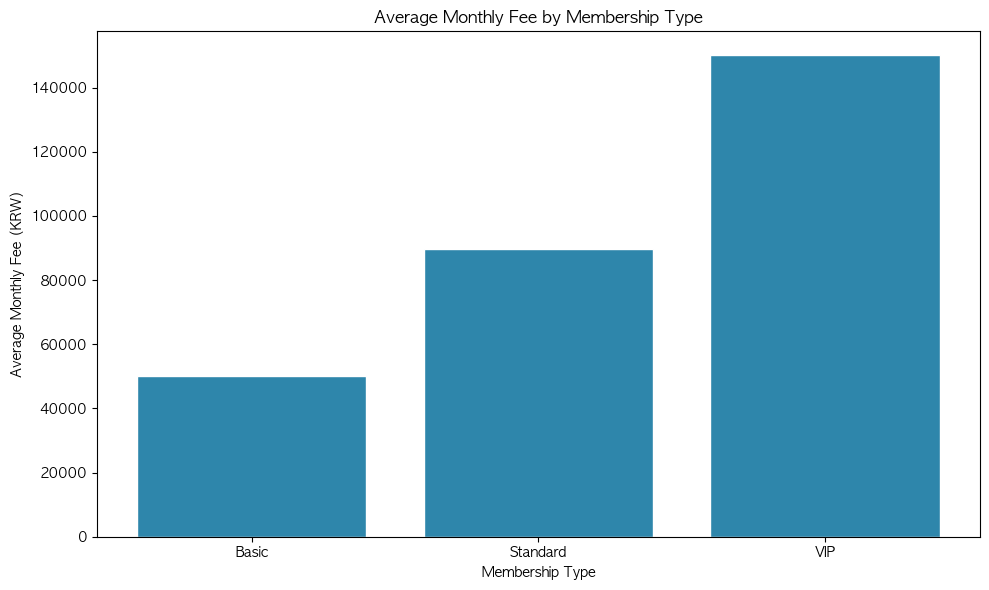

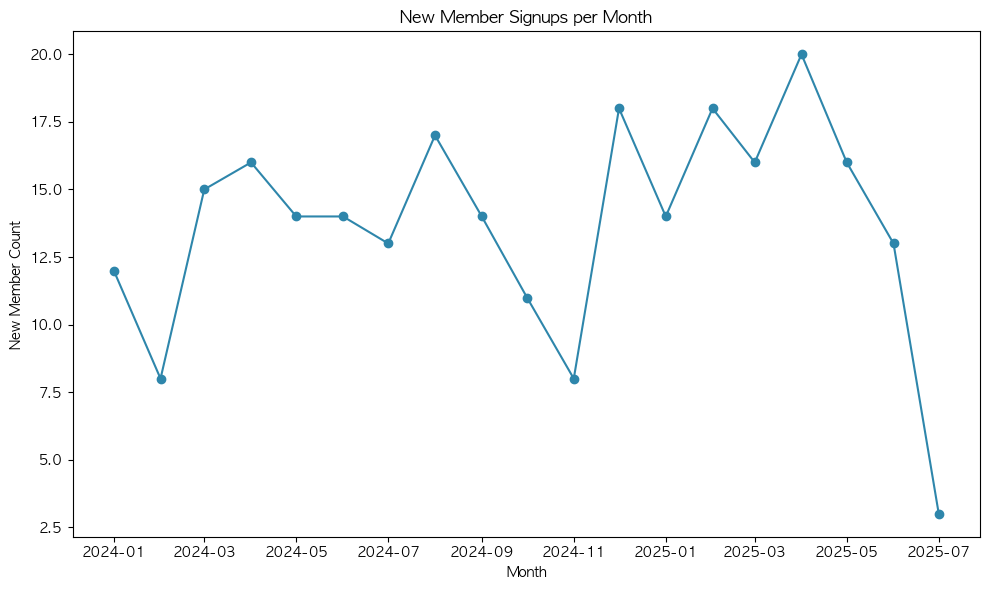

In [53]:
# Visualization
import matplotlib.pyplot as plt
# import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'   # macOS: 'AppleGothic', Windows: 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Chart 1: Average monthly fee by membership type (bar chart, use the cleaned data)
data = df[(df["monthly_fee"] > 0) & (df["monthly_fee"] < 1_000_000)].groupby("membership_type")["monthly_fee"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(data.index, data.values, color='#2E86AB', edgecolor='white')
ax.set_title('Average Monthly Fee by Membership Type')
ax.set_xlabel('Membership Type')
ax.set_ylabel('Average Monthly Fee (KRW)')
plt.tight_layout()
plt.show()

# Chart 2: New member signups per month (bar or line chart, use the cleaned data)
data = df.groupby(df['signup_date'].dt.to_period('M'))['member_id'].count()
data.index = data.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(data.index, data.values, color='#2E86AB', marker='o')
ax.set_title('New Member Signups per Month')
ax.set_xlabel('Month')
ax.set_ylabel('New Member Count')
plt.tight_layout()
plt.show()


---
# 💼 Business Insights
*What did I discover?*

- Raw exports need a checklist first: 14 duplicate rows and an empty `notes` column would distort any member count.  
  (원본은 먼저 체크리스트. 중복 14건과 빈 notes를 두면 회원 수가 왜곡됨)
- `membership_type` had 14 spellings of 3 plans. Basic is the largest group (116), VIP the smallest (40).  
  (등급 표기 14개는 요금제 3개의 철자 문제. Basic 116명으로 가장 많고 VIP는 40명)
- Four invalid fees (0, 0, -50,000, 5,000,000) must stay out of the average. Then plan prices are ~50k / ~90k / ~150k.  
  (회비 이상 4건은 평균에서 제외. 그러면 요금제는 약 5만 / 9만 / 15만 원)


---
# 🎯 Business Recommendation
*If I were the Business Analyst...*

1. Report plan prices from the filtered mean (~50k / ~90k / ~150k), not from the raw mean that included the 5,000,000 row.  
   (요금 보고는 이상 4건을 뺀 평균(~5만/9만/15만)을 쓸 것. 500만 원이 포함된 평균은 쓰지 말 것)
2. Standardize membership type at import (strip / allowed list: VIP, Standard, Basic) so unique count stays at 3.  
   (적재 시 등급을 VIP / Standard / Basic만 허용하게 표준화)
3. Do not treat July 2025 as a demand drop until a full month of signups is in.  
   (2025년 7월을 수요 급락으로 보지 말 것. 한 달이 끝나기 전임)


---
# ❌ Mistakes
*What mistakes did I make today?*

- Called `.title()` on a Series (`str.strip().title()`) instead of `.str.title()`.  
  (strip 다음에 `.str` 없이 `.title()`을 호출)
- Used `.str.title()` on `VIP`, which became `Vip`.  
  (VIP가 title 때문에 Vip가 됨)
- Copied `edgecolor` from the bar chart onto `ax.plot`, and plotted a PeriodIndex without `to_timestamp()`.  
  (선 그래프에 막대용 edgecolor를 넣음. Period 인덱스를 timestamp로 안 바꿈)


---
# ✅ What I Learned
*Today's biggest lesson*

- Clean before you average. A string fee column and four bad numbers will break the chart.  
  (평균 전에 정제. 문자 회비와 이상값 4건이면 차트가 깨짐)
- `.str` is required on every string method in a chain. `title()` is not a Series method.  
  (문자열 메서드마다 `.str`이 필요. title은 Series 메서드가 아님)
- Monthly charts need a month key (`dt.to_period('M')`), not the raw date.  
  (월별 차트는 날짜 전체가 아니라 월 키가 필요)


---
# 🧠 Reflection

**What was difficult?**  
Knowing which cleaning belongs in the checklist cell vs Q1–Q3, and getting string methods / the monthly line chart to run.  
(체크리스트 셀과 Q1~Q3 중 어디에 수정을 둘지, 문자열 메서드와 월별 선 차트)

**Why?**  
The template has both a Data Cleaning section and questions that *are* cleaning. Bar-chart kwargs also do not work on `plot`.  
(템플릿에 클리닝 칸과 클리닝 질문이 같이 있음. 막대 옵션은 plot에 안 먹음)

**How did I solve it?**  
Scan in Data Cleaning, fix in Q1–Q3. Use `.str.strip().str.title()` and replace `Vip`. Convert PeriodIndex with `to_timestamp()`.  
(클리닝 칸은 확인, 수정은 Q1~Q3. str 체이닝과 Vip 치환. Period는 timestamp로)

**What would I do differently next time?**  
Print raw unique / missing counts *before* changing the column. Check chart kwargs against bar vs line.  
(컬럼을 바꾸기 전에 unique·결측을 먼저 출력. 차트 옵션이 bar인지 line인지 확인)


---
# ⭐ Self Evaluation

**Understanding**  
⭐⭐⭐⭐⭐⭐☆☆☆☆  
Checklist cleaning and groupby are clearer; `.str` chaining and Period vs timestamp are still new.  
(체크리스트 클리닝과 groupby는 이해됨. str 체이닝과 Period vs timestamp는 아직 새로움)

**Confidence**  
⭐⭐⭐⭐⭐⭐☆☆☆☆  
Can find missing values, dups, and bad fees. Less sure about when a mean is still dirty.  
(결측·중복·이상 회비는 찾을 수 있음. 평균이 아직 더러운지는 덜 확실)

**Difficulty**  
⭐⭐⭐⭐⭐⭐☆☆☆☆  
The messy table was the point of the day. Syntax errors on `.str` and `plot` took extra time.  
(지저분한 표가 오늘의 핵심. str과 plot 문법에서 시간이 더 걸림)


---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 04 — visualization basics (막대·선 차트 기본)
